<a id="step-1"></a>

## Step 1: Importing libraries

Before you start working on the dataset, it is good practice to import all libraries at the beginning of your code. 


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from math import sqrt

<a id="step-2"></a>

## Step 2: Load and Clean the Data

<a id="load-the-data"></a>

### Load the Data

In [ ]:
# Load the data
df = pd.read_csv("data/LoanData.csv")
df.head()

,LoanId,NewCreditCustomer,LoanDate,VerificationType,Age,Gender,Country,AppliedAmount,Amount,Interest,...,EmploymentDurationCurrentEmployer,HomeOwnershipType,IncomeTotal,ExistingLiabilities,LiabilitiesTotal,RefinanceLiabilities,Rating,NoOfPreviousLoansBeforeLoan,AmountOfPreviousLoansBeforeLoan,PreviousEarlyRepaymentsCountBeforeLoan
0,D8EBF360-104C-420F-BEC9-000924E6EFC7,False,2022-09-09,By Bank Statement,27,Female,EE,3189.0,3189.0,35.48,...,UpTo5Years,Other,900.0,0,0.00,0,D,1.0,3402.0,0.0
1,C1A98DDA-5E20-429C-BBFF-0009A05354E0,False,2023-05-19,By Bank Statement,35,Female,FI,4146.0,4146.0,19.86,...,UpTo5Years,Owner,3100.0,0,0.00,0,B,1.0,518.0,0.0
2,9B0B252E-45B9-4172-8E2D-0014A8F18117,False,2024-02-03,By Bank Statement,23,Male,EE,531.0,531.0,19.52,...,UpTo5Years,TenantFurnished,1700.0,0,0.00,0,B,3.0,1593.0,0.0
3,66AE108B-532B-4BB3-BAB7-0019A46412C1,False,2016-03-23,By Bank Statement,53,Female,EE,2125.0,2125.0,20.97,...,MoreThan5Years,Owner,354.0,8,485.09,6,C,1.0,500.0,0.0
4,C7EA512A-465D-4043-A9F2-001B14C3C14E,False,2023-09-26,By Bank Statement,43,Male,FI,414.0,414.0,19.89,...,Other,TenantFurnished,1200.0,0,0.00,0,D,5.0,11198.0,0.0


<a id="cleaning-the-dataset"></a>

### Cleaning the Dataset


In [ ]:
# set the "LoanId" column as index
df.set_index(df["LoanId"], inplace = True)


In [ ]:
df.index.name

'LoanId'

<a id="step-3"></a>

## Step 3: Retrieving key metrics
To recommend loan offers, take a moment to understand the loan amounts and ratings. You’ll also want to get a rough idea of the interest rates being paid.

<a id="describing-the-dataset"></a>

### Describing the dataset 



In [ ]:
# find the sample mean and std of the "Interest" column
interest_mean = df["Interest"].mean()
interest_std = df["Interest"].std()

# find the number of borrowers that received a smaller "Amount" than they asked for ("AppliedAmount")
num_less_amount = (df["Amount"] < df["AppliedAmount"]).sum()

# find the proportion of loan ratings
rating_proportion = df["Rating"].value_counts()/len(df)

In [ ]:
# print the results
print("Interest rate mean:", round(interest_mean, 2))
print("Interest rate standard deviation:", round(interest_std,2))
print("Number of borrowers that received less money than they asked for:", num_less_amount)
print("Proportion of loan ratings:\n", rating_proportion.sort_index())

Interest rate mean: 27.29
Interest rate standard deviation: 18.03
Number of borrowers that received less money than they asked for: 10543
Proportion of loan ratings:
 Rating
A     0.043291
AA    0.024826
B     0.179124
C     0.317741
D     0.206457
E     0.115707
F     0.074443
HR    0.038411
Name: count, dtype: float64


<a id="high-risk-customers"></a>

### High-Risk Customers

Customers with a high debt-to-income ratio and less job stability may have more difficulty repaying loans, making them riskier.

<a id="ex3"></a>

In [ ]:
# create the column "DebtToIncome" 
df["DebtToIncome"] = df["Amount"]/df["IncomeTotal"]

# create a new column "IsRisky" that is True if the loan is risky
df["IsRisky"] = (df["DebtToIncome"] >= 0.35) & (df["EmploymentDurationCurrentEmployer"].isin(["TrialPeriod", "UpTo1Year"]))

# calculate the proportion of risky loans
risky_proportion = df["IsRisky"].sum()/len(df)

# calculate the mean interest rate of the risky loans
mean_interest_risky = df[df["IsRisky"] == 1]["Interest"].mean()

# calculate the mean interest rate of the non-risky loans
mean_interest_non_risky = df[df["IsRisky"] == 0]["Interest"].mean()

In [ ]:
# print the results
print("Risky loans proportion:", round(risky_proportion, 4))
print("Mean interest rate of risky loans:", round(mean_interest_risky, 4))
print("Mean interest rate of non-risky loans:", round(mean_interest_non_risky, 4))

Risky loans proportion: 0.1588
Mean interest rate of risky loans: 28.8592
Mean interest rate of non-risky loans: 26.9899


<a id="step-4"></a>

## Step 4: Understanding different customer profiles

As a fintech analyst, understanding customer profiles allows us to identify patterns. We want to understand how different factors of the borrowers influence loan applications. 

<a id="visualization-of-different-profiles"></a>

### Visualization of different profiles




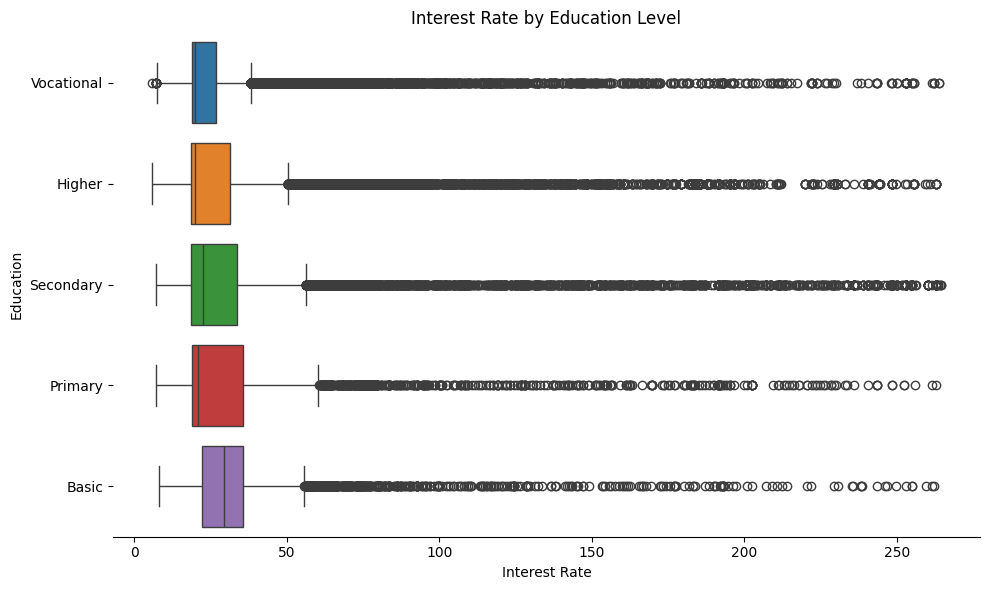

In [ ]:
# create the figure with size (10,6)
plt.figure(figsize=(10,6))

# create the interest rate by segmentation plot
boxplot_ax = sns.boxplot(df, x = "Interest", y = "Education", hue = "Education")

# set the x-axis label
plt.xlabel("Interest Rate")

# set the title
plt.title("Interest Rate by Education Level")

# despine the plot
sns.despine(left = True)

plt.tight_layout()
plt.show()

<a id="ex5"></a>

#### Exercise 5: Scatter plots and correlation
We also want to investigate the relationship between certain numerical features and the interest rate. For that, you decide to use scatter plots, along with the correlation between features.

Correlation between Interest Rate and LoanDuration:
-0.0106
Correlation between Interest Rate and IncomeTotal:
-0.0122
Correlation between Interest Rate and AmountOfPreviousLoansBeforeLoan:
-0.175
Correlation between Interest Rate and DebtToIncome:
-0.0053


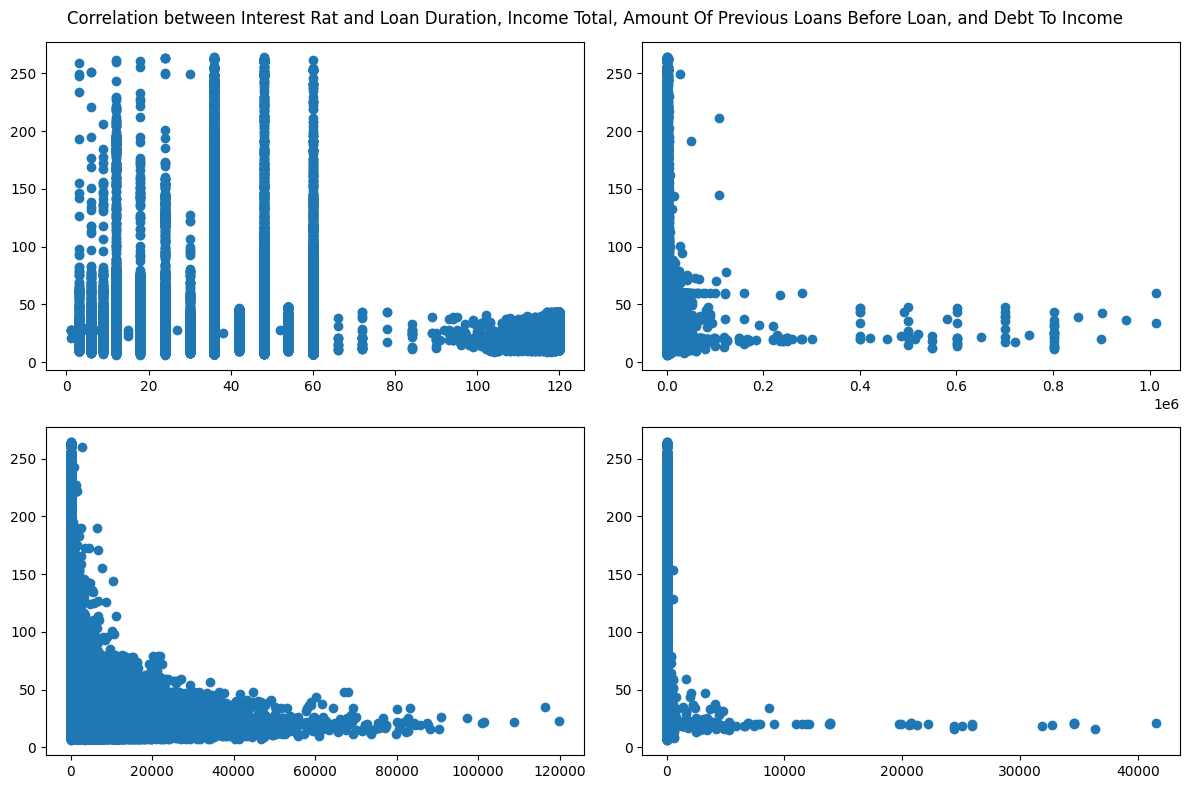

In [ ]:
scatterplot_fig = plt.figure(figsize=(12, 8))

# create a list to store the correlation values
correlation = []

# create a list of segmentation columns
corr_columns = ["LoanDuration", "IncomeTotal", "AmountOfPreviousLoansBeforeLoan", 
               "DebtToIncome"]

# iterate over the values 1-4 (one for each subplot)
for i in range(1,5):

    # get the column name. Remember subtract 1 from i to match the list's indexing
    column_name = corr_columns[i-1]

    # create the subplot. Remember the arguments are (rows, columns, index)
    plt.subplot(2,2,i)

    # create scatter plot
    plt.scatter(x = df[column_name], y = df["Interest"])

    # calculate the correlation between the column and the interest rate
    corr = corr = df[column_name].corr(df["Interest"])


    # append the correlation value to the list
    correlation.append(corr)

    # print the results
    print("Correlation between Interest Rate and " + column_name+ ":\n"+ str(round(corr,4))) 

# set the general title
plt.suptitle("Correlation between Interest Rat and Loan Duration, Income Total, Amount Of Previous Loans Before Loan, and Debt To Income")

plt.tight_layout()
plt.show()

<a id="applied-and-received-amounts"></a>

### Applied and Received Amounts
We noticed that there are two similar columns, "AppliedAmount" and "Amount", in the dataset. This implies that sometimes borrowers get loaned a different amount than what they asked for. 

<a id="ex6"></a>



In [ ]:
# get the number of samples where "AppliedAmount" differs from the requested "Amount"
num_differences = (df["Amount"]< df["AppliedAmount"]).sum()

# get the total number of samples
n = len(df)

# calculate the sample proportion
phat = num_differences/n

# calculate the standard error for proportions
se = sqrt(phat*(1-phat)/n)

# build the confidence interval
confidence_interval = stats.norm.interval(confidence=0.95, loc = phat, scale = se)

In [ ]:
print("The 95% confidence interval is", confidence_interval)

The 95% confidence interval is (np.float64(0.02698232853687249), np.float64(0.028017645379482474))


<a id="step-5"></a>

## Step 5: Modelling the Interest Rate
To make personalized loan offers, we have to go one step further in your analysis and build a model to predict interest rates using different customer features. This will help us both be able to predict interest rates for new customers, and observe which features are actually statistically significant in determining the interest rates. 

<a id="categorical-features"></a>

### Simple Linear Regression

To get our first model going you begin creating a simple linear regression. Based on the correlation analysis you we did before, a good candidate for the independent variable is "AmountOfPreviousLoansBeforeLoan", which presented the strongest correlation with the target variable `"Interest"`. 

<a id="ex7"></a>


In [ ]:
# prepare predictors. do not forget to add the constant term
X_simple = sm.add_constant(df["AmountOfPreviousLoansBeforeLoan"])

# select the dependent variable
Y_simple = df["Interest"]

# build the model
model_simple = sm.OLS(Y_simple, X_simple)

# fit the model
results_simple = model_simple.fit()

# Print the results summary
print(results_simple.summary())

                            OLS Regression Results                            
Dep. Variable:               Interest   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                 1.211e+04
Date:                Thu, 04 Jun 2026   Prob (F-statistic):               0.00
Time:                        03:07:04   Log-Likelihood:            -1.6468e+06
No. Observations:              383382   AIC:                         3.294e+06
Df Residuals:                  383380   BIC:                         3.294e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

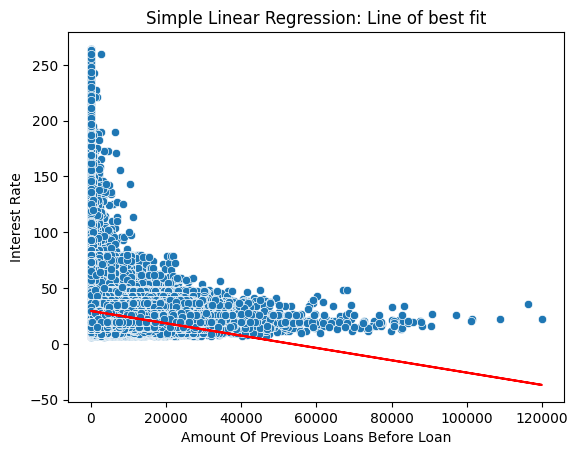

In [ ]:
plt.figure()
sns.scatterplot(data=df, x="AmountOfPreviousLoansBeforeLoan", y="Interest")
plt.plot(df["AmountOfPreviousLoansBeforeLoan"], results_simple.predict(X_simple), color="red")
plt.title("Simple Linear Regression: Line of best fit")
plt.xlabel("Amount Of Previous Loans Before Loan")
plt.ylabel("Interest Rate")
plt.show()